# RB1S (RBOB) — Feature Engineering for Metamodel

This notebook engineers RB1S-specific features (crack spreads, seasonality, rolling vols, interactions) and prepares a `rb1s_model_features.csv` for modeling.


In [1]:
# Install dependencies (uncomment to run if needed)
# %pip install pandas numpy matplotlib seaborn xgboost scikit-learn


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')

DATA_DIR = Path('MetaModel')
OHLCV_PATH = DATA_DIR / 'ohlcv_data.csv'
PRIMARY_SIGNALS_PATH = DATA_DIR / 'primary_signals.csv'
LABELED_PATH = DATA_DIR / 'labeled_signals.csv'

print('Data paths:')
print(OHLCV_PATH)
print(PRIMARY_SIGNALS_PATH)
print(LABELED_PATH)


Data paths:
MetaModel\ohlcv_data.csv
MetaModel\primary_signals.csv
MetaModel\labeled_signals.csv


In [ ]:
ohlcv = pd.read_csv('ohlcv_data.csv', parse_dates=['date'])
print('ohlcv shape', ohlcv.shape)

primary_signals = pd.read_csv('primary_signals.csv', parse_dates=['date'])
print('primary_signals shape', primary_signals.shape)

labeled = pd.read_csv('labeled_signals.csv', parse_dates=['date'])
print('labeled_signals shape', labeled.shape)

# Keep only instruments of interest and lowercase instrument names
ohlcv['instrument'] = ohlcv['instrument'].str.lower()
insts = ['rb1s','cl1s','ho1s']
ohlcv = ohlcv[ohlcv['instrument'].isin(insts)].copy()

# Pivot close prices to wide form
close_wide = ohlcv.pivot_table(index='date', columns='instrument', values='close')
close_wide = close_wide.sort_index()
print('close_wide columns:', close_wide.columns.tolist())


ohlcv shape (83547, 8)
primary_signals shape (645, 12)
labeled_signals shape (1176, 6)
close_wide columns: ['cl1s', 'ho1s', 'rb1s']


In [4]:
# Compute RB-specific features
features = pd.DataFrame(index=close_wide.index)

if 'cl1s' in close_wide.columns and 'rb1s' in close_wide.columns:
    features['crack_cl_rb'] = close_wide['cl1s'] - close_wide['rb1s']
    features['crack_cl_rb_ratio'] = close_wide['cl1s'] / close_wide['rb1s']
else:
    print('CL1S or RB1S not present — skipping crack features')

if 'ho1s' in close_wide.columns and 'rb1s' in close_wide.columns:
    features['rb_vs_ho'] = close_wide['rb1s'] - close_wide['ho1s']
    features['rb_vs_ho_ratio'] = close_wide['rb1s'] / close_wide['ho1s']

# Term structure / roll proxy: use 21-day forward - current if front-month futures present
# If futures columns like rb1s_1m exist, user may adjust; here we compute simple momentum proxies
features['rb_close'] = close_wide.get('rb1s')
features['rb_ret_1d'] = features['rb_close'].pct_change(1)
features['rb_ret_3d'] = features['rb_close'].pct_change(3)
features['rb_ret_5d'] = features['rb_close'].pct_change(5)

# Rolling volatility
features['rb_vol_10d'] = features['rb_ret_1d'].rolling(10).std()
features['rb_vol_20d'] = features['rb_ret_1d'].rolling(20).std()

# Volume / OI features from ohlcv if present
vol_wide = ohlcv.pivot_table(index='date', columns='instrument', values='volume')
if 'rb1s' in vol_wide.columns:
    features['rb_volume'] = vol_wide['rb1s']
    features['rb_volume_z_20'] = (features['rb_volume'] - features['rb_volume'].rolling(20).mean()) / features['rb_volume'].rolling(20).std()

# Seasonality
features['month'] = features.index.month
features['is_summer'] = features['month'].isin([4,5,6,7,8,9]).astype(int)
features['dayofweek'] = features.index.dayofweek

# EWMA/decay features
features['rb_ewm_ret_5'] = features['rb_ret_1d'].ewm(span=5).mean()

# Interaction example
if 'crack_cl_rb' in features.columns and 'rb_vol_10d' in features.columns:
    features['crack_x_vol'] = features['crack_cl_rb'] * features['rb_vol_10d']

features = features.reset_index().rename(columns={'index':'date'})
print('Engineered features shape:', features.shape)
features.head()


Engineered features shape: (8171, 18)


C:\Users\Georgia\AppData\Local\Temp\ipykernel_35804\1707598781.py:17: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  features['rb_ret_1d'] = features['rb_close'].pct_change(1)
C:\Users\Georgia\AppData\Local\Temp\ipykernel_35804\1707598781.py:18: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  features['rb_ret_3d'] = features['rb_close'].pct_change(3)
C:\Users\Georgia\AppData\Local\Temp\ipykernel_35804\1707598781.py:19: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct

,date,crack_cl_rb,crack_cl_rb_ratio,rb_vs_ho,rb_vs_ho_ratio,rb_close,rb_ret_1d,rb_ret_3d,rb_ret_5d,rb_vol_10d,rb_vol_20d,rb_volume,rb_volume_z_20,month,is_summer,dayofweek,rb_ewm_ret_5,crack_x_vol
0,1990-01-02,22.2331,34.845486,-0.1170,0.848818,0.6569,NaN,NaN,NaN,NaN,NaN,13854.0,NaN,1,0,1,NaN,NaN
1,1990-01-03,23.0077,35.222371,-0.1097,0.859719,0.6723,0.023443,NaN,NaN,NaN,NaN,12399.0,NaN,1,0,2,0.023443,NaN
2,1990-01-04,22.7571,35.855414,-0.0790,0.892062,0.6529,-0.028856,NaN,NaN,NaN,NaN,12314.0,NaN,1,0,3,-0.007936,NaN
3,1990-01-05,22.4578,37.094182,-0.0561,0.917293,0.6222,-0.047021,-0.052824,NaN,NaN,NaN,10698.0,NaN,1,0,4,-0.026450,NaN
4,1990-01-08,21.0352,36.969904,-0.0585,0.909063,0.5848,-0.060109,-0.130150,NaN,NaN,NaN,8661.0,NaN,1,0,0,-0.040432,NaN


In [5]:
# Merge with primary signals and labeled (if present) to build model dataset for RB1S
# primary_signals is wide-format (date + instrument columns) — melt to long if present
if primary_signals is not None:
    primary_long = primary_signals.melt(id_vars='date', var_name='instrument', value_name='signal')
    primary_long['instrument'] = primary_long['instrument'].str.lower()
else:
    primary_long = None

if labeled is not None:
    labeled['instrument'] = labeled['instrument'].str.lower()

# Keep only RB1S rows
model_features = features.copy()
model_features['instrument'] = 'rb1s'

if primary_long is not None:
    model_features = model_features.merge(
        primary_long[primary_long['instrument']=='rb1s'][['date','signal']],
        on='date', how='left'
    )
else:
    model_features['signal'] = np.nan

if labeled is not None:
    model_features = model_features.merge(
        labeled[labeled['instrument']=='rb1s'][['date','label']],
        on='date', how='left'
    )
else:
    model_features['label'] = np.nan

print('model_features shape:', model_features.shape)
model_features.head()


model_features shape: (8171, 21)


,date,crack_cl_rb,crack_cl_rb_ratio,rb_vs_ho,rb_vs_ho_ratio,rb_close,rb_ret_1d,rb_ret_3d,rb_ret_5d,rb_vol_10d,...,rb_volume,rb_volume_z_20,month,is_summer,dayofweek,rb_ewm_ret_5,crack_x_vol,instrument,signal,label
0,1990-01-02,22.2331,34.845486,-0.1170,0.848818,0.6569,NaN,NaN,NaN,NaN,...,13854.0,NaN,1,0,1,NaN,NaN,rb1s,NaN,NaN
1,1990-01-03,23.0077,35.222371,-0.1097,0.859719,0.6723,0.023443,NaN,NaN,NaN,...,12399.0,NaN,1,0,2,0.023443,NaN,rb1s,NaN,NaN
2,1990-01-04,22.7571,35.855414,-0.0790,0.892062,0.6529,-0.028856,NaN,NaN,NaN,...,12314.0,NaN,1,0,3,-0.007936,NaN,rb1s,NaN,NaN
3,1990-01-05,22.4578,37.094182,-0.0561,0.917293,0.6222,-0.047021,-0.052824,NaN,NaN,...,10698.0,NaN,1,0,4,-0.026450,NaN,rb1s,NaN,NaN
4,1990-01-08,21.0352,36.969904,-0.0585,0.909063,0.5848,-0.060109,-0.130150,NaN,NaN,...,8661.0,NaN,1,0,0,-0.040432,NaN,rb1s,NaN,NaN


Saved


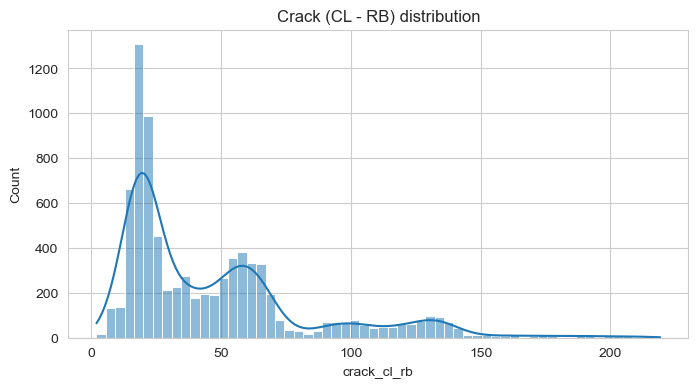

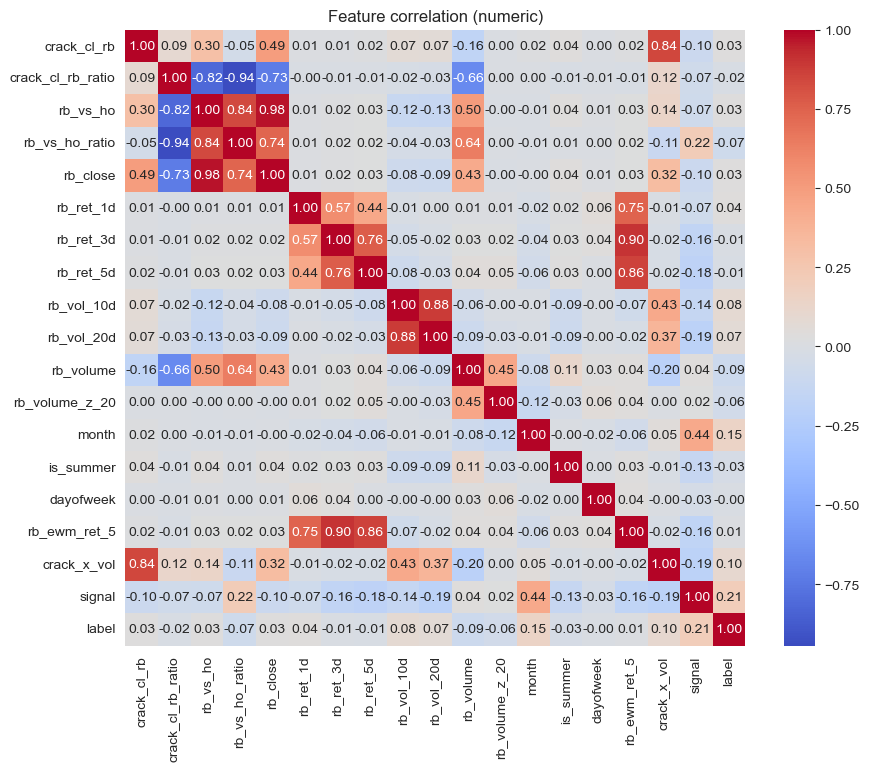

In [7]:
# Save model features for later modeling

model_features.to_csv('rb1s_model_features.csv', index=False)
print('Saved')

# Quick exploratory plots
plt.figure(figsize=(8,4))
if 'crack_cl_rb' in model_features.columns:
    sns.histplot(model_features['crack_cl_rb'].dropna(), bins=60, kde=True)
    plt.title('Crack (CL - RB) distribution')
    plt.show()

# Correlation heatmap of numeric features
num_cols = model_features.select_dtypes(include=[np.number]).columns.tolist()
if num_cols:
    corr = model_features[num_cols].corr()
    plt.figure(figsize=(10,8))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Feature correlation (numeric)')
    plt.show()


In [ ]:
# Build RB1S modeling dataset from engineered features and label set
model_source = model_features.copy() if 'model_features' in globals() else features.copy()
model_source['instrument'] = 'rb1s'
model_source['date'] = pd.to_datetime(model_source['date'])

primary_signals = pd.read_csv(DATA_DIR / 'primary_signals.csv', parse_dates=['date'])
primary_long = primary_signals.melt(
    id_vars='date',
    var_name='instrument',
    value_name='signal'
)

labeled = labeled.drop(columns=['signal'], errors='ignore')

primary_long['date'] = pd.to_datetime(primary_long['date'])
primary_long['instrument'] = primary_long['instrument'].str.lower()
model_source['instrument'] = model_source['instrument'].str.lower()
labeled['date'] = pd.to_datetime(labeled['date'])
labeled['instrument'] = labeled['instrument'].str.lower()

rb_signals = primary_long[primary_long['instrument'] == 'rb1s'][['date', 'instrument', 'signal']]
rb_labels = labeled[labeled['instrument'] == 'rb1s'][['date', 'instrument', 'label']]

model_df = model_source.merge(rb_signals, on=['date', 'instrument'], how='inner')
print("After signal merge:", len(model_df), "rows")

model_df = model_df.merge(rb_labels, on=['date', 'instrument'], how='inner')
print("After label merge:", len(model_df), "rows")

model_df = model_df[model_df['signal'] != 0].reset_index(drop=True)
print("After filtering signal != 0:", len(model_df), "rows")

print(model_df.head())
print('\nModel dataset columns:', model_df.columns.tolist())

After first merge: 2512 rows
After second merge: 1176 rows
After filtering signal != 0: 1176 rows
        date instrument  signal  level_0  index       open       high  \
0 2020-01-07       cl1s      -1     7545   7545  25.496729  25.593998   
1 2020-01-22       cl1s      -1     7555   7555  23.599977  23.648586   
2 2020-01-23       cl1s      -1     7556   7556  22.729054  22.793867   
3 2020-01-24       cl1s      -1     7557   7557  22.558920  22.664241   
4 2020-01-27       cl1s      -1     7558   7558  21.752811  21.756861   

         low      close        volume  ...    atr_14  mom_rank  vol_rank  \
0  25.172498  25.411618  1.437614e+06  ...  0.471293       1.0      0.25   
1  22.696648  22.984255  1.530855e+06  ...  0.751701       1.0      0.50   
2  22.186246  22.518412  1.737915e+06  ...  0.780911       1.0      0.75   
3  21.813573  21.951300  1.447108e+06  ...  0.755983       1.0      0.50   
4  21.116834  21.525966  1.759849e+06  ...  0.755373       1.0      0.75   

   hmm

loaded MetaModel\rb1s_model_features.csv shape= (8171, 21)


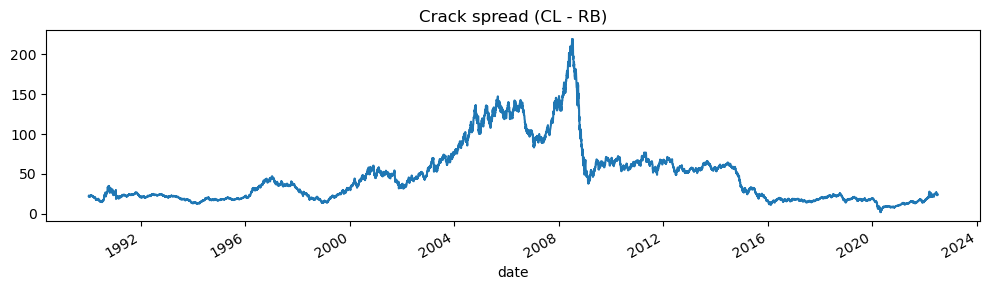

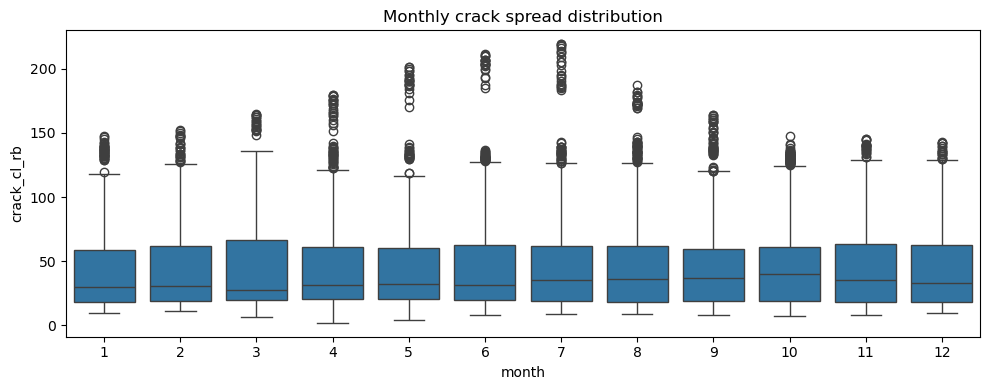

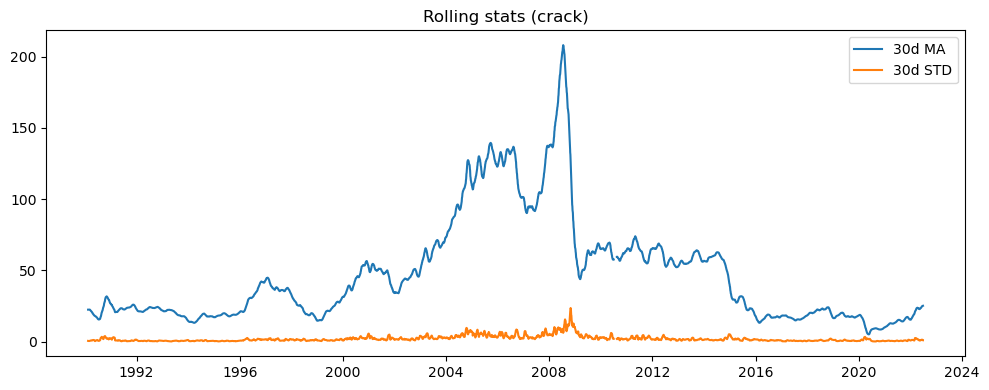

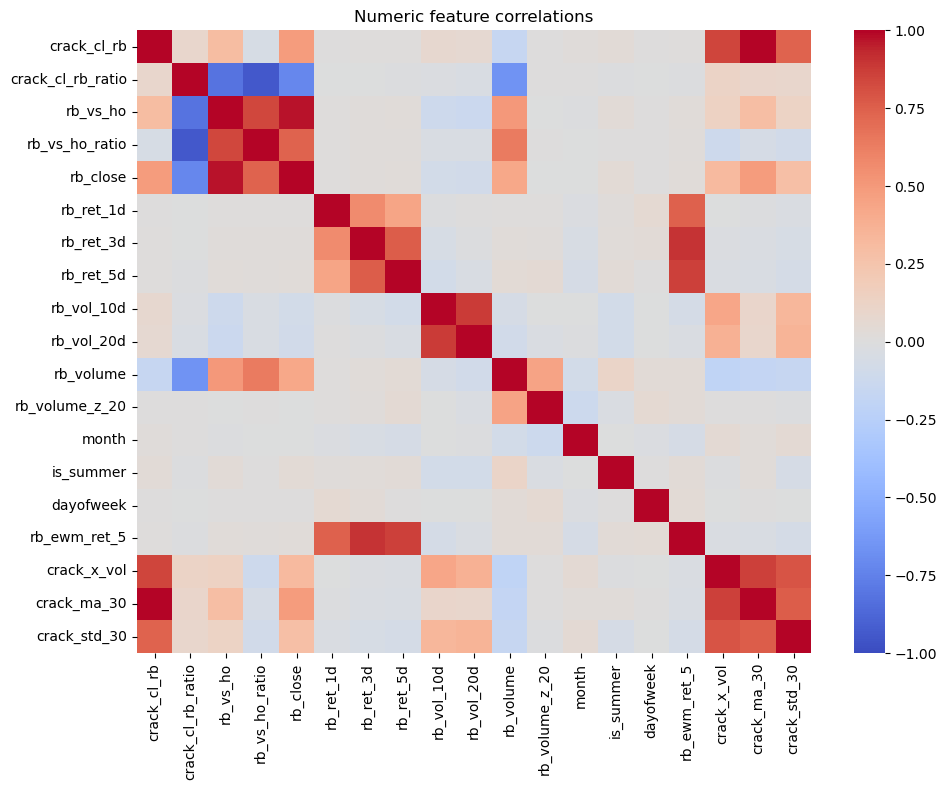

Missingness (fraction):
label                0.927304
signal               0.923143
crack_ma_30          0.007221
crack_std_30         0.007221
rb_volume_z_20       0.004773
rb_vol_20d           0.002448
crack_x_vol          0.001346
rb_vol_10d           0.001224
rb_ret_5d            0.000612
rb_ret_3d            0.000367
rb_vs_ho             0.000245
rb_vs_ho_ratio       0.000245
crack_cl_rb          0.000122
crack_cl_rb_ratio    0.000122
rb_close             0.000122
rb_volume            0.000122
rb_ret_1d            0.000122
rb_ewm_ret_5         0.000122
dtype: float64


In [2]:
# EDA: Inspect RB1S features
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


df = pd.read_csv('rb1s_model_features.csv', parse_dates=['date'])
df = df.sort_values('date')
print('loaded', fn, 'shape=', df.shape)

# Time series of crack spread
if 'crack_cl_rb' in df.columns:
    plt.figure(figsize=(10,3))
    df.set_index('date')['crack_cl_rb'].dropna().plot()
    plt.title('Crack spread (CL - RB)')
    plt.tight_layout(); plt.show()

# Monthly boxplot to show seasonality
if 'crack_cl_rb' in df.columns:
    df['month'] = df['date'].dt.month
    plt.figure(figsize=(10,4))
    sns.boxplot(x='month', y='crack_cl_rb', data=df[df['crack_cl_rb'].notna()])
    plt.title('Monthly crack spread distribution')
    plt.tight_layout(); plt.show()

# Rolling mean/std
if 'crack_cl_rb' in df.columns:
    df['crack_ma_30'] = df['crack_cl_rb'].rolling(30).mean()
    df['crack_std_30'] = df['crack_cl_rb'].rolling(30).std()
    plt.figure(figsize=(10,4))
    plt.plot(df['date'], df['crack_ma_30'], label='30d MA')
    plt.plot(df['date'], df['crack_std_30'], label='30d STD')
    plt.legend(); plt.title('Rolling stats (crack)'); plt.tight_layout(); plt.show()

# Correlation heatmap for numeric features
num = df.select_dtypes(include='number').copy()
drop_cols = [c for c in ['signal','label'] if c in num.columns]
num = num.drop(columns=drop_cols, errors='ignore')
if num.shape[1] > 1:
    corr = num.corr()
    plt.figure(figsize=(10,8))
    sns.heatmap(corr, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title('Numeric feature correlations')
    plt.tight_layout(); plt.show()

# Quick missingness summary
miss = df.isna().mean().sort_values(ascending=False)
print('Missingness (fraction):')
print(miss[miss>0].head(20))


In [6]:
# add a HMM model using RB1S crack-spread feature signals

from hmmlearn.hmm import GaussianHMM
from sklearn.preprocessing import StandardScaler


def fit_hmm(df_instrument, feature_cols, n_states=3):
    """
    Fit HMM on one instrument's features.
    Returns the instrument df with new columns: hmm_state, hmm_prob_0, hmm_prob_1, hmm_prob_2.
    """
    df_instrument = df_instrument.copy()
    available_features = [c for c in feature_cols if c in df_instrument.columns]
    if not available_features:
        raise ValueError(f"No available HMM features in instrument data: {feature_cols}")

    X = df_instrument[available_features].dropna()
    if len(X) < n_states + 5:
        df_instrument.loc[X.index, "hmm_state"] = np.nan
        for k in range(n_states):
            df_instrument.loc[X.index, f"hmm_prob_{k}"] = np.nan
        return df_instrument

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    model = GaussianHMM(n_components=n_states, covariance_type="diag",
                        n_iter=100, random_state=42)
    model.fit(X_scaled)

    states = model.predict(X_scaled)
    probs = model.predict_proba(X_scaled)

    df_instrument.loc[X.index, "hmm_state"] = states
    for k in range(n_states):
        df_instrument.loc[X.index, f"hmm_prob_{k}"] = probs[:, k]

    return df_instrument


HMM_FEATURES = [
    "crack_cl_rb", "crack_cl_rb_ratio",
    "rb_vs_ho", "rb_vs_ho_ratio",
    "rb_ret_1d", "rb_ret_3d", "rb_ret_5d",
    "rb_vol_10d", "rb_vol_20d",
    "rb_volume_z_20", "rb_ewm_ret_5",
    "crack_x_vol"
]

if "instrument" not in df.columns:
    df["instrument"] = "rb1s"

results = []
for instr, grp in df.groupby("instrument"):
    grp = grp.sort_values("date")
    grp_with_hmm = fit_hmm(grp, HMM_FEATURES, n_states=3)
    results.append(grp_with_hmm)

if results:
    df = pd.concat(results).sort_values(["instrument", "date"]).reset_index(drop=True)

print(df[["instrument", "hmm_state", "hmm_prob_0", "hmm_prob_1", "hmm_prob_2"]].dropna().head(10))

  instrument  hmm_state  hmm_prob_0     hmm_prob_1     hmm_prob_2
0       rb1s        0.0         1.0  7.012308e-272  9.187537e-120
1       rb1s        0.0         1.0   5.319355e-21   3.396852e-13
2       rb1s        0.0         1.0   7.533445e-20   4.188612e-13
3       rb1s        0.0         1.0   3.158233e-15   1.505834e-10
4       rb1s        0.0         1.0   4.552510e-17   1.661433e-11
5       rb1s        0.0         1.0   3.620151e-18   4.707726e-12
6       rb1s        0.0         1.0   9.573591e-19   3.099852e-12
7       rb1s        0.0         1.0   9.322227e-19   1.799830e-12
8       rb1s        0.0         1.0   1.109759e-18   7.030642e-13
9       rb1s        0.0         1.0   1.315621e-19   4.845596e-13


c:\Users\Georgia\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\Georgia\AppData\Local\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Georgia\AppData\Local\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Georgia\AppData\Local\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, 

In [7]:
# What does each state look like on average?
df.groupby(["instrument", "hmm_state"])[HMM_FEATURES].mean().round(3)


crack_cl_rb  crack_cl_rb_ratio  rb_vs_ho  \
instrument hmm_state                                             
rb1s       0.0             13.513              3.787     3.496   
           1.0              7.247              4.124     1.494   
           2.0             22.988              3.454     6.268   

                      rb_vs_ho_ratio  rb_ret_1d  rb_ret_3d  rb_ret_5d  \
instrument hmm_state                                                    
rb1s       0.0                 3.435      0.002      0.006      0.010   
           1.0                 2.770     -0.007     -0.008     -0.004   
           2.0                 3.023      0.005      0.014      0.023   

                      rb_vol_10d  rb_vol_20d  rb_volume_z_20  rb_ewm_ret_5  \
instrument hmm_state                                                         
rb1s       0.0             0.019       0.019           0.013         0.002   
           1.0             0.065       0.070          -0.071        -0.002   
           2.0             0.032       0.031           0.065         0.005   

                      crack_x_vol  
instrument hmm_state               
rb1s       0.0              0.244  
           1.0              0.433  
           2.0              0.704

In [13]:
# triple barrier labeling function
# will save the file under same name, only one instrument if in this file, or all 4 commodities if in the other
# metamodel_1 file

from triple_barrier import run_labeling, sensitivity_analysis
labeled = run_labeling(instruments=['rb1s']) 

Loading data...
  Labeling RB1S... 594 labels  (+1: 306, -1: 288)

Saved labeled_signals.csv  (594 total rows)


In [14]:
print(labeled.head())
print(labeled['label'].value_counts())  # how balanced are 0s and 1s?

        date instrument  signal  entry_price     atr14  label
0 2020-01-03       rb1s       1     5.764619  0.116797     -1
1 2020-01-06       rb1s       1     5.783078  0.119425     -1
2 2020-01-07       rb1s      -1     5.676937  0.125825      1
3 2020-01-08       rb1s       1     5.434986  0.159489     -1
4 2020-01-09       rb1s       1     5.447842  0.159458     -1
label
 1    306
-1    288
Name: count, dtype: int64


In [23]:
# Rebuild the RB1S modeling dataset using the current feature DataFrame and generated label set

if 'model_features' in globals() and isinstance(model_features, pd.DataFrame):
    model_source = model_features.copy()
elif 'df' in globals() and isinstance(df, pd.DataFrame):
    model_source = df.copy()
elif 'features' in globals() and isinstance(features, pd.DataFrame):
    model_source = features.copy()
else:
    raise NameError('No feature DataFrame found in notebook variables. Re-run the feature engineering cells first.')

model_source['instrument'] = 'rb1s'
model_source['date'] = pd.to_datetime(model_source['date'])

primary_signals = pd.read_csv('primary_signals.csv', parse_dates=['date'])
primary_long = primary_signals.melt(
    id_vars='date',
    var_name='instrument',
    value_name='signal'
)
print(primary_long.head())

labeled = labeled.drop(columns=['signal'], errors='ignore')

primary_long['date'] = pd.to_datetime(primary_long['date'])
primary_long['instrument'] = primary_long['instrument'].str.lower()
model_source['instrument'] = model_source['instrument'].str.lower()
labeled['date'] = pd.to_datetime(labeled['date'])
labeled['instrument'] = labeled['instrument'].str.lower()

rb_signals = primary_long[primary_long['instrument'] == 'rb1s'][['date', 'instrument', 'signal']]
rb_labels = labeled[labeled['instrument'] == 'rb1s'][['date', 'instrument', 'label']]

print('RB signals rows:', len(rb_signals))
print('RB labels rows:', len(rb_labels))

model_df = model_source.merge(rb_signals, on=['date', 'instrument'], how='inner')
print('After signal merge:', len(model_df), 'rows')

model_df = model_df.merge(rb_labels, on=['date', 'instrument'], how='inner')
print('After label merge:', len(model_df), 'rows')

#model_df = model_df.reset_index(drop=True)

model_df = model_df[model_df['signal'] != 0].reset_index(drop=True)
print('After filtering signal != 0:', len(model_df), 'rows')

print(model_df.head())
print('\nModel dataset columns:', model_df.columns.tolist())

        date instrument  signal
0 2020-01-03       es1s       1
1 2020-01-06       es1s       1
2 2020-01-07       es1s       1
3 2020-01-08       es1s       1
4 2020-01-09       es1s       1
RB signals rows: 645
RB labels rows: 594
After signal merge: 594 rows
After label merge: 594 rows


KeyError: 'signal'